# Un termitero inspira cómo recuperar 83% del vapor industrial

Una planta de 300 MW tira al aire **270 millones de toneladas de agua al año** en forma de vapor. Basta con mirar cómo enfrían los termiteros africanos para recuperar el 83%.

**Paper:** A bioinspired hierarchical architecture for the high-yield recovery of industrial water vapour · *Nature Water, 2026-04-21*
**DOI:** [10.1038/s44221-026-00635-8](https://doi.org/10.1038/s44221-026-00635-8)
**Datos:** Supplementary Information + Source Data (Springer)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-21-vapor-agua-termitero-industrial/notebook.ipynb)

📺 Video corto en YouTube: *Pendiente*


## El problema (y el modelo biológico)

Las torres de enfriamiento de centrales térmicas, petroquímicas y químicas son enormes chimeneas de vapor: disipan el calor sobrante evaporando agua, y esa agua —litros por segundo— se pierde en la atmósfera.

Los termiteros de África sí saben retener humedad: los obreros construyen una red de cámaras, chimeneas y canales que enfría por dentro sin ventilador y sin perder agua. El equipo de Zhang copió esa idea en cuatro capas apiladas (cuatro *tiers*):

1. **Tier 1** — un recubrimiento de microesferas que nuclea gotas rápido (33,6 g/m²/min).
2. **Tier 2** — pirámides invertidas que agrandan el área de transferencia de calor.
3. **Tier 3** — enfriamiento radiativo que baja la superficie 1,7 °C por debajo del punto de rocío.
4. **Tier 4** — canales biomiméticos que evitan que el vapor recuperado se disperse.

La pregunta del notebook: **¿cuánto aporta cada tier, y qué significa esto a escala industrial?**


In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
RETENCION_OBJETIVO = 83.5          # % del sistema completo a t=24 min
RETENCION_BASELINE = 27.2          # % del sistema sin tiers
RECOVERY_KG_M2_DAY = 41.6          # recovery rate reportado
CHINA_AHORRO_TONNES_YR = 270_000_000  # 2,7×10^8 t/yr planta 300 MW
FUENTE = 'Fuente: Zhang et al. (2026), Nature Water | Datos: Supplementary Info'

COLOR_DATOS = '#2563EB'       # azul CaM — sistema completo
COLOR_ALERTA = '#DC2626'      # rojo — baseline, contraste
COLOR_SECUNDARIO = '#059669'  # emerald — tiers intermedios
COLOR_REFERENCIA = '#D97706'  # amber — referencia / umbral
COLOR_VIOLETA = '#7C3AED'     # violeta — correlaciones
COLOR_CONTEXTO = '#BBBBBB'    # gris — contexto histórico

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Cargar estilo CaM (local → /tmp → GitHub raw)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

# Cargar datasets
wet = pd.read_csv('datos/wettability_coatings.csv')
ret = pd.read_csv('datos/retention_vs_time.csv')
countries = pd.read_csv('datos/country_savings.csv')
therm = pd.read_csv('datos/thermal_conductivity.csv')

print(f'Humectabilidad: {len(wet)} recubrimientos')
print(f'Retención: {len(ret)} puntos en el tiempo × {len(ret.columns)-1} sistemas')
print(f'Países: {len(countries)} · Conductividad: {len(therm)} temperaturas')
print(f'\nRetención a t=24 min:')
print(f'  - baseline:      {ret.iloc[-1]["baseline_pct"]:.1f}%')
print(f'  - sistema full:  {ret.iloc[-1]["full_system_pct"]:.1f}%')
print(f'  - diferencia:    +{ret.iloc[-1]["full_system_pct"] - ret.iloc[-1]["baseline_pct"]:.1f} pp')


Humectabilidad: 5 recubrimientos
Retención: 7 puntos en el tiempo × 5 sistemas
Países: 14 · Conductividad: 7 temperaturas

Retención a t=24 min:
  - baseline:      27.2%
  - sistema full:  83.5%
  - diferencia:    +56.3 pp


## La curva

Aquí está.


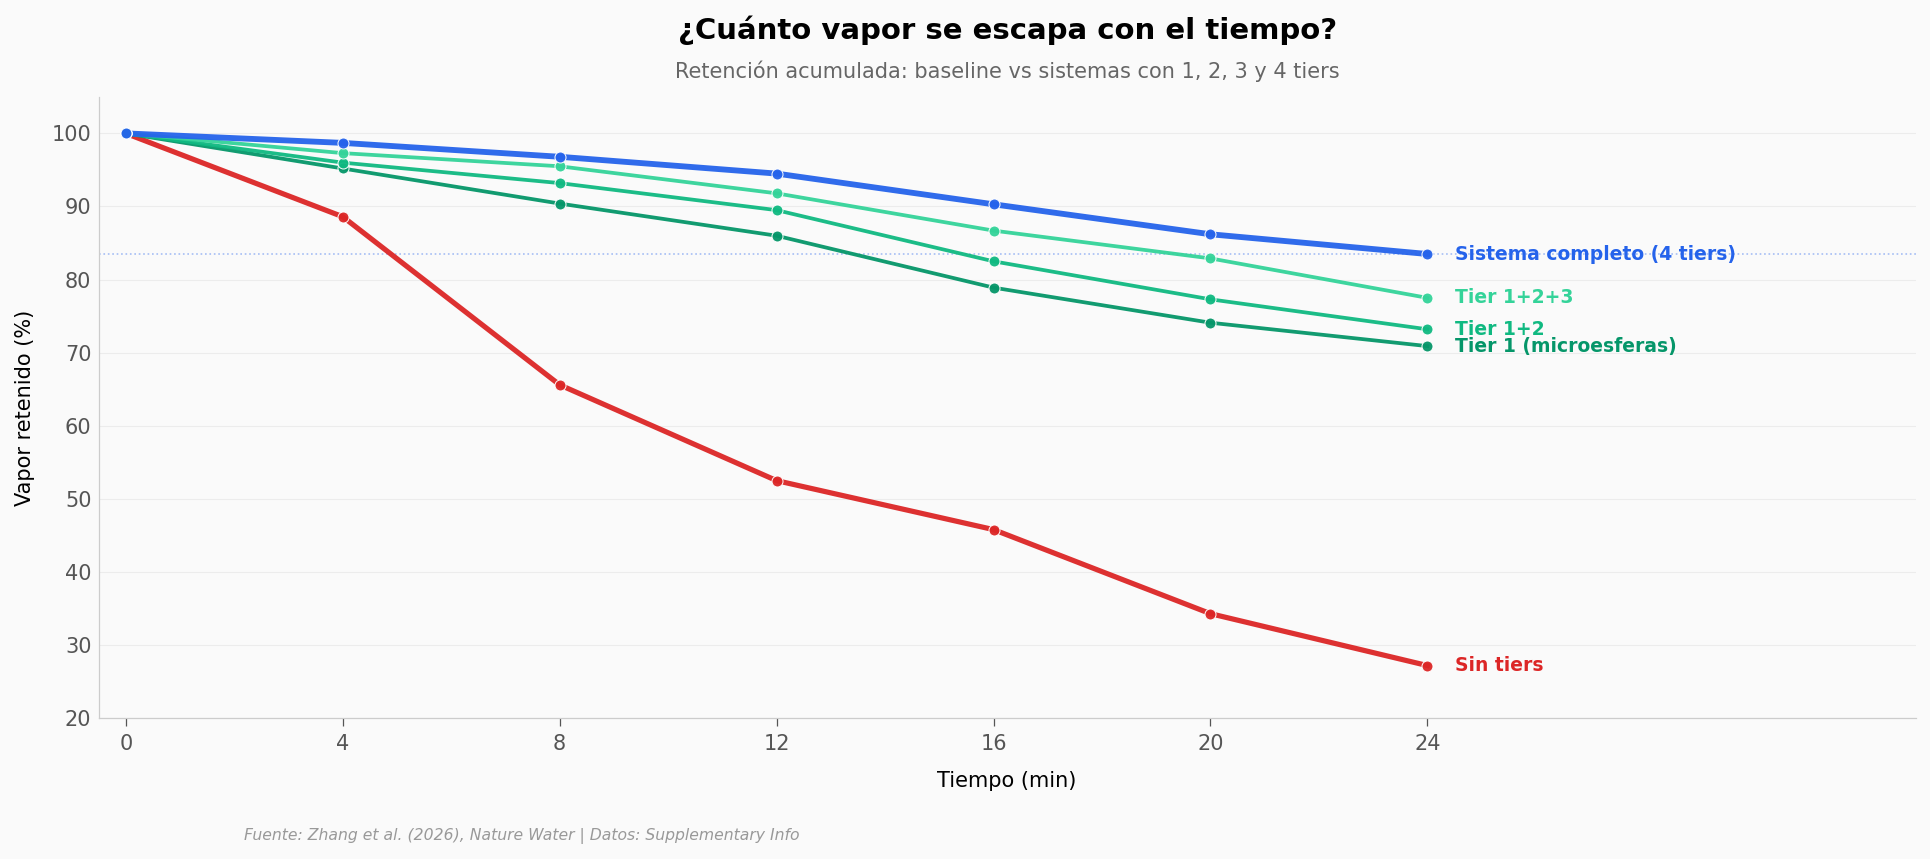

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

tiempo = ret['tiempo_min']
systems = [
    ('baseline_pct',    'Sin tiers',                COLOR_ALERTA,      2.5),
    ('tier1_pct',       'Tier 1 (microesferas)',    COLOR_SECUNDARIO,  1.8),
    ('tier2_pct',       'Tier 1+2',                 '#10B981',         1.8),
    ('tier3_pct',       'Tier 1+2+3',               '#34D399',         1.8),
    ('full_system_pct', 'Sistema completo (4 tiers)', COLOR_DATOS,     2.8),
]
for col, label, color, lw in systems:
    ax.plot(tiempo, ret[col], color=color, linewidth=lw, alpha=0.95, zorder=5)
    ax.scatter(tiempo, ret[col], color=color, s=28, alpha=0.95,
               edgecolors='white', linewidths=0.5, zorder=6)
    # inline label al final de cada curva
    y_end = ret[col].iloc[-1]
    ax.text(24.5, y_end, label, fontsize=9, color=color,
            fontweight='bold', va='center', ha='left')

ax.axhline(y=RETENCION_OBJETIVO, color=COLOR_DATOS, linewidth=0.8,
           linestyle=':', alpha=0.4, zorder=1)

ax.set_xlabel('Tiempo (min)', fontsize=10)
ax.set_ylabel('Vapor retenido (%)', fontsize=10)
ax.set_title('¿Cuánto vapor se escapa con el tiempo?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Retención acumulada: baseline vs sistemas con 1, 2, 3 y 4 tiers',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.set_xlim(-0.5, 33)
ax.set_ylim(20, 105)
ax.set_xticks([0, 4, 8, 12, 16, 20, 24])

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/retencion_hero.png', dpi=200, bbox_inches='tight')
plt.show()


## Lo que llama la atención

A los 24 minutos el baseline ya perdió **tres cuartas partes** del vapor (sólo retiene 27,2%). El sistema completo retiene 83,5% — un salto de +56,3 puntos porcentuales.

Pero la curva no cae parejo entre sistemas. La distancia entre "Tier 1" y "Sistema completo" es mucho menor que entre "baseline" y "Tier 1". El primer tier hace casi todo el trabajo; los siguientes tres apenas lo refinan.

Veamos eso con más claridad.


## ¿Qué aporta cada tier?

Descomponemos los +56,3 pp ganados a t=24 min: cuánto añade cada capa sobre la anterior.


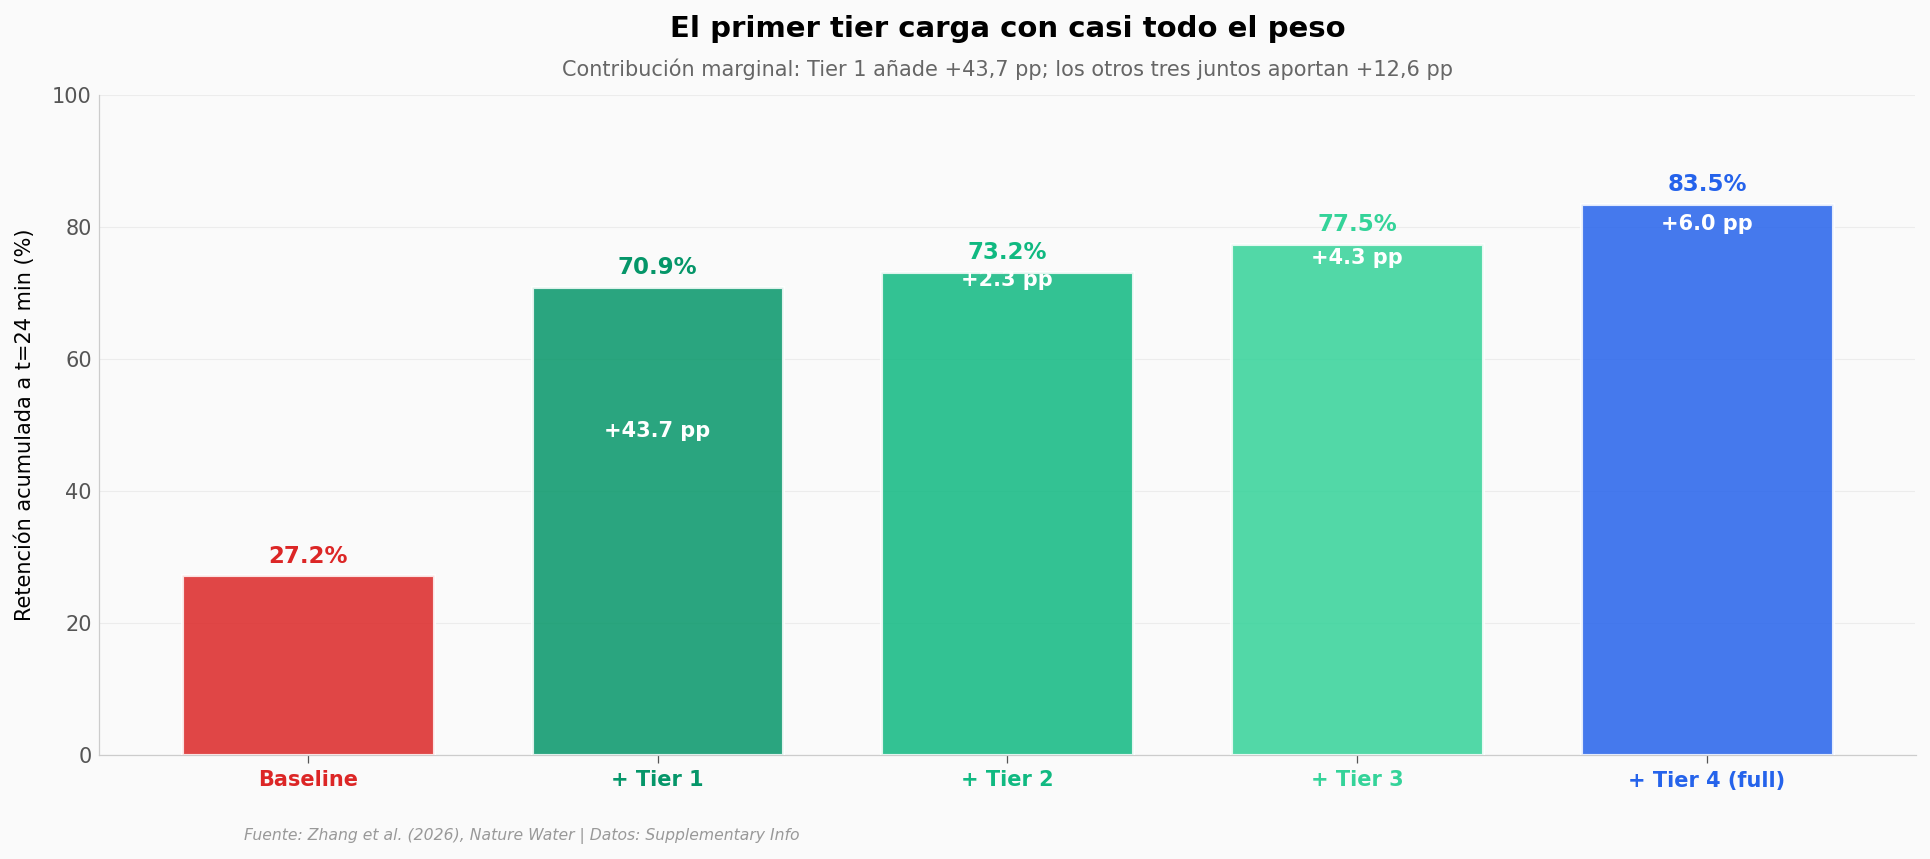

In [3]:
# Contribuciones por tier a t=24 min (puntos porcentuales sobre el previo)
t24 = ret.iloc[-1]
contribs = [
    ('Baseline',        t24['baseline_pct'],        0,                                  COLOR_ALERTA),
    ('+ Tier 1',        t24['tier1_pct'],           t24['tier1_pct']     - t24['baseline_pct'], COLOR_SECUNDARIO),
    ('+ Tier 2',        t24['tier2_pct'],           t24['tier2_pct']     - t24['tier1_pct'],    '#10B981'),
    ('+ Tier 3',        t24['tier3_pct'],           t24['tier3_pct']     - t24['tier2_pct'],    '#34D399'),
    ('+ Tier 4 (full)', t24['full_system_pct'],     t24['full_system_pct'] - t24['tier3_pct'],  COLOR_DATOS),
]

fig, ax = plt.subplots(figsize=(13, 5.5))
positions = np.arange(len(contribs))
tops = [c[1] for c in contribs]
deltas = [c[2] for c in contribs]

for i, (label, top, delta, color) in enumerate(contribs):
    ax.bar(i, top, color=color, alpha=0.85, edgecolor='white',
           linewidth=1.5, zorder=5, width=0.72)
    # Etiqueta superior: valor
    ax.text(i, top + 1.2, f'{top:.1f}%', ha='center', va='bottom',
            fontsize=11, fontweight='bold', color=color, zorder=6)
    # Delta (excepto el baseline)
    if i > 0:
        ax.annotate(f'+{delta:.1f} pp',
                    xy=(i, top - delta/2),
                    ha='center', va='center',
                    fontsize=10, fontweight='bold',
                    color='white', zorder=7)

ax.set_xticks(positions)
ax.set_xticklabels([c[0] for c in contribs], fontsize=10, fontweight='bold')
for tick, (_, _, _, color) in zip(ax.get_xticklabels(), contribs):
    tick.set_color(color)

ax.set_ylabel('Retención acumulada a t=24 min (%)', fontsize=10)
ax.set_title('El primer tier carga con casi todo el peso',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Contribución marginal: Tier 1 añade +43,7 pp; los otros tres juntos aportan +12,6 pp',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylim(0, 100)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/tier_contribuciones.png', dpi=200, bbox_inches='tight')
plt.show()


## El corazón del Tier 1: un recubrimiento raro

Si una sola capa aporta +43,7 pp, vale mirar qué tiene de especial. La clave está en el recubrimiento **FAUTO**, una mezcla heterogénea de dos químicas.

En química de superficies hay dos medidas típicas:

- **Ángulo de contacto (CA):** qué tan curvada queda una gota quieta. Alto = la gota se mantiene redonda (superficie hidrófoba). Bajo = la gota se aplana (hidrófila).
- **Ángulo de deslizamiento (SA):** qué inclinación hace falta para que la gota empiece a rodar. Bajo = la gota se desliza fácil. Alto = la gota queda pegada.

Normalmente, si CA es alto el SA es bajo (como en una hoja de loto). FAUTO rompe esa regla.


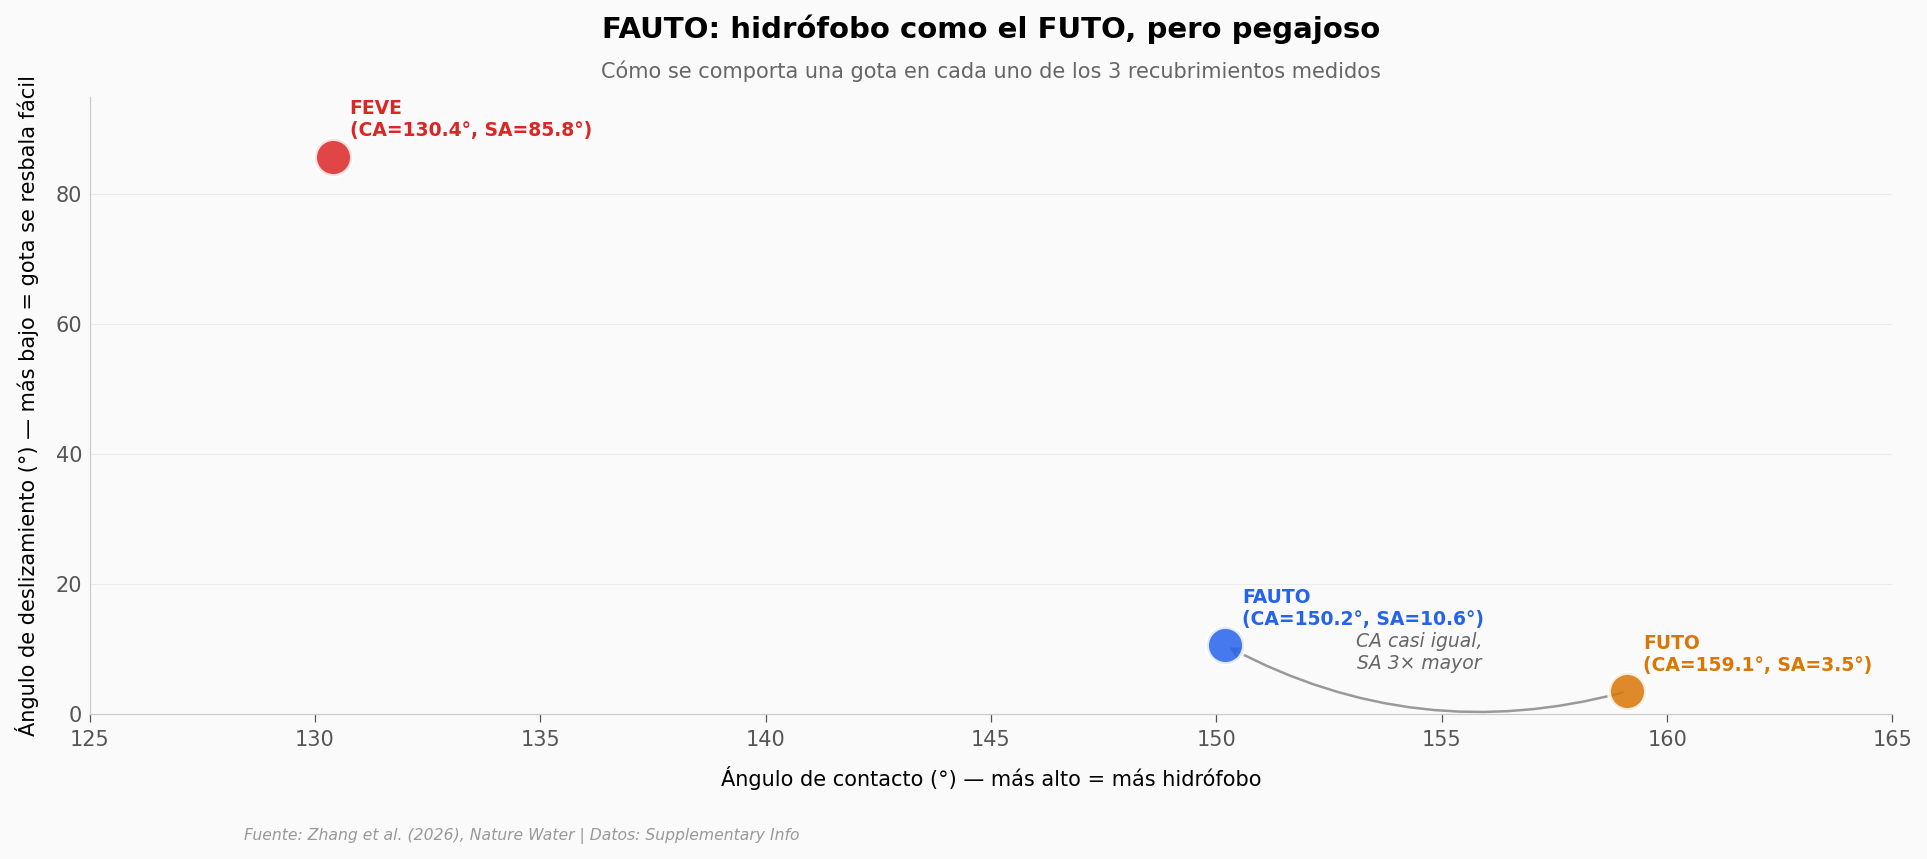

In [4]:
# Comparar los 5 recubrimientos
# AUTO y PEBN no tienen SA reportado (son hidrófilos/hidrófobos simples)
wet_plot = wet.dropna(subset=['sliding_angle_deg']).copy()

fig, ax = plt.subplots(figsize=(13, 5.5))

palette = {
    'FEVE_coating':  COLOR_ALERTA,
    'FUTO_coating':  COLOR_REFERENCIA,
    'FAUTO_coating': COLOR_DATOS,
}
for _, row in wet_plot.iterrows():
    color = palette.get(row['sample'], '#888888')
    ax.scatter(row['contact_angle_deg'], row['sliding_angle_deg'],
               s=320, color=color, alpha=0.85,
               edgecolors='white', linewidths=2, zorder=5)
    label = row['sample'].replace('_coating', '')
    ax.annotate(f"{label}\n(CA={row['contact_angle_deg']:.1f}°, SA={row['sliding_angle_deg']:.1f}°)",
                xy=(row['contact_angle_deg'], row['sliding_angle_deg']),
                xytext=(8, 8), textcoords='offset points',
                fontsize=9, fontweight='bold', color=color, va='bottom')

# Resaltar la regla que FAUTO rompe: línea diagonal "superhidrófobo ideal" (CA alto → SA bajo)
futo = wet_plot[wet_plot['sample'] == 'FUTO_coating'].iloc[0]
fauto = wet_plot[wet_plot['sample'] == 'FAUTO_coating'].iloc[0]
ax.annotate('', xy=(fauto['contact_angle_deg'], fauto['sliding_angle_deg']),
            xytext=(futo['contact_angle_deg'], futo['sliding_angle_deg']),
            arrowprops=dict(arrowstyle='->', color='#999999', lw=1.2,
                            connectionstyle='arc3,rad=-0.2'))
ax.text(154.5, 7, 'CA casi igual,\nSA 3× mayor',
        fontsize=9, color='#666666', style='italic', ha='center')

ax.set_xlabel('Ángulo de contacto (°) — más alto = más hidrófobo', fontsize=10)
ax.set_ylabel('Ángulo de deslizamiento (°) — más bajo = gota se resbala fácil', fontsize=10)
ax.set_title('FAUTO: hidrófobo como el FUTO, pero pegajoso',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cómo se comporta una gota en cada uno de los 3 recubrimientos medidos',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(125, 165)
ax.set_ylim(0, 95)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/wettability.png', dpi=200, bbox_inches='tight')
plt.show()


## ¿Y si lo escaláramos?

El paper plantea una proyección: si una central térmica de 300 MW adoptara este sistema, ¿cuánta agua recuperaría al año? La respuesta depende del clima local (temperatura, humedad).

Los autores simularon 14 países con generación térmica significativa. El CSV reporta el ahorro relativo de cada país respecto a China (`ratio_vs_china`). Anclamos esa escala al valor que el abstract asigna a China — **2,7×10⁸ toneladas por planta por año** — para obtener las cifras absolutas proyectadas. Esto es modelo, no medida experimental.


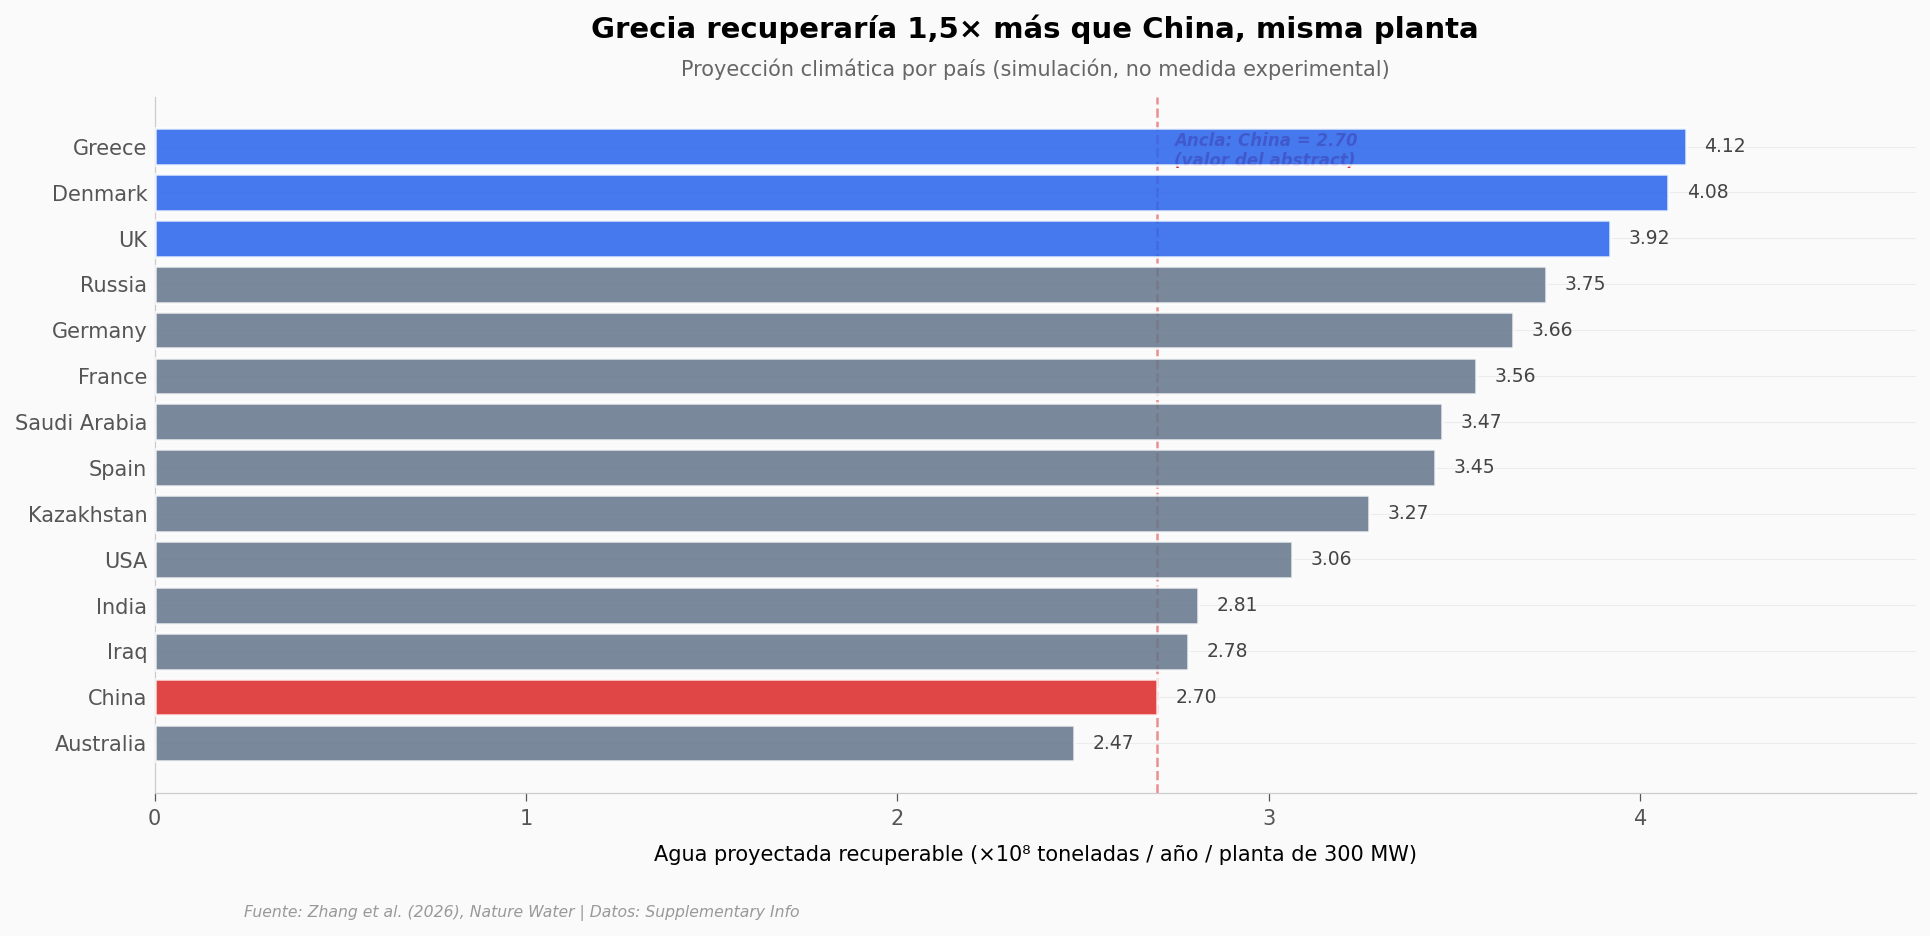


Rango proyectado: 2.47 (Australia) -> 4.12 (Grecia) x10^8 t/yr
Ratio mejor/peor clima: 1.67x
Desviacion estandar: 0.530 x10^8 t/yr


In [5]:
# Anclamos la cifra por país al valor del abstract para China (2,7×10^8 t/yr)
# usando el ratio_vs_china del CSV — asi reproducimos exactamente la cifra del abstract
# y mantenemos la estructura relativa de los 14 climas.
c_sorted = countries.sort_values('ratio_vs_china', ascending=True).copy()
c_sorted['tonnes_x1e8'] = c_sorted['ratio_vs_china'] * (CHINA_AHORRO_TONNES_YR / 1e8)

fig, ax = plt.subplots(figsize=(13, 6))

colors = []
for country in c_sorted['country']:
    if country == 'China':
        colors.append(COLOR_ALERTA)  # referencia del abstract
    elif country in ('Greece', 'Denmark', 'UK'):
        colors.append(COLOR_DATOS)
    else:
        colors.append('#64748B')

bars = ax.barh(c_sorted['country'], c_sorted['tonnes_x1e8'],
               color=colors, alpha=0.85, edgecolor='white', linewidth=1.2, zorder=5)

# Anotar el valor al final de cada barra
for bar, val in zip(bars, c_sorted['tonnes_x1e8']):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9, color='#444444')

# Línea de referencia: China = 2,7
china_val = c_sorted[c_sorted['country'] == 'China']['tonnes_x1e8'].iloc[0]
ax.axvline(x=china_val, color=COLOR_ALERTA, linewidth=1.2,
           linestyle='--', alpha=0.5, zorder=1)
ax.annotate(f'Ancla: China = {china_val:.2f}\n(valor del abstract)',
            xy=(china_val, 0.95), xycoords=('data', 'axes fraction'),
            xytext=(8, 0), textcoords='offset points',
            fontsize=8, color=COLOR_ALERTA, fontweight='bold',
            style='italic', va='top', ha='left')

ax.set_xlabel('Agua proyectada recuperable (×10⁸ toneladas / año / planta de 300 MW)', fontsize=10)
ax.set_title('Grecia recuperaría 1,5× más que China, misma planta',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Proyección climática por país (simulación, no medida experimental)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(0, c_sorted['tonnes_x1e8'].max() * 1.15)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/country_savings.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"\nRango proyectado: {c_sorted['tonnes_x1e8'].min():.2f} (Australia) -> "
      f"{c_sorted['tonnes_x1e8'].max():.2f} (Grecia) x10^8 t/yr")
print(f"Ratio mejor/peor clima: {c_sorted['tonnes_x1e8'].max() / c_sorted['tonnes_x1e8'].min():.2f}x")
print(f"Desviacion estandar: {c_sorted['tonnes_x1e8'].std():.3f} x10^8 t/yr")


### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| "83% de retención a t=24 min" | ✅ | Sistema completo = 83,5% en el CSV; el paper reporta 83% redondeado |
| "2,7×10⁸ toneladas/año para planta 300 MW" | ⚠️ | El abstract lo enmarca como proyección. El CSV solo reporta ratios entre países (`ratio_vs_china`); anclamos esa escala al valor del abstract para China. La estructura relativa es dato; la magnitud absoluta es proyección |
| "Recuperación 41,6 kg/m²/día" | ⚠️ | No está en estos CSV — el paper lo reporta; los datos públicos solo muestran rango 33,8–45,0 kg/m²/día (SI Fig.45) |
| "Tier 1 aporta la mayoría de la retención" | ✅ | Contribución marginal a t=24 min: Tier 1 = +43,7 pp, los otros tres juntos = +12,6 pp |
| "FAUTO es superhidrófobo" | ⚠️ | CA=150,2° está en el rango superhidrófobo (>150°), pero SA=10,6° es tres veces el del FUTO (3,5°); el paper lo enmarca como "mezcla heterogénea", no como superhidrófobo puro |
| "Grecia ahorra 1,5× más que China" | ✅ | Cociente exacto desde `ratio_vs_china` del CSV: 1,527× (Grecia = 1,527, China = 1,000) |

> **Limitaciones:**
> - Los ahorros por país son **proyecciones climáticas**, no medidas experimentales. Asumen que una planta de 300 MW opera de forma idéntica en todos los países y que el único factor que cambia es el clima local. No modelan diferencias de humedad del vapor emitido, mantenimiento, degradación de los recubrimientos.
> - El sistema fue probado en laboratorio a escala pequeña (paneles, no una torre completa). Escalar 4 tiers a una torre de enfriamiento real implica ingeniería civil no abordada por el paper.
> - La tabla de humectabilidad solo reporta SA para 3 de los 5 recubrimientos (PEBN y AUTO no tienen SA medido).


## Ahora tú

El notebook está parametrizado. Copia una celda de código, modifica los valores y corre de nuevo.

**Preguntas para explorar:**

1. **¿Cómo cambia la conductividad térmica con la temperatura?** Los datos `thermal_conductivity.csv` miden 5 muestras (C1–C5) entre 273 y 333 K. Grafica cada columna contra la temperatura. ¿Cuál muestra enfría mejor a temperatura alta?
2. **¿A qué temperatura el C5 supera al C3 (referencia PEBN)?** Pista: `therm['k_c5'] > therm['k_c3_pebn_ref']`.
3. **¿Y si la planta fuera de 600 MW?** Duplica los ahorros proyectados y responde: ¿cuántos hogares serviría el doble de Grecia? El paper dice que 300 MW en China alcanza para 2,2 millones de hogares.


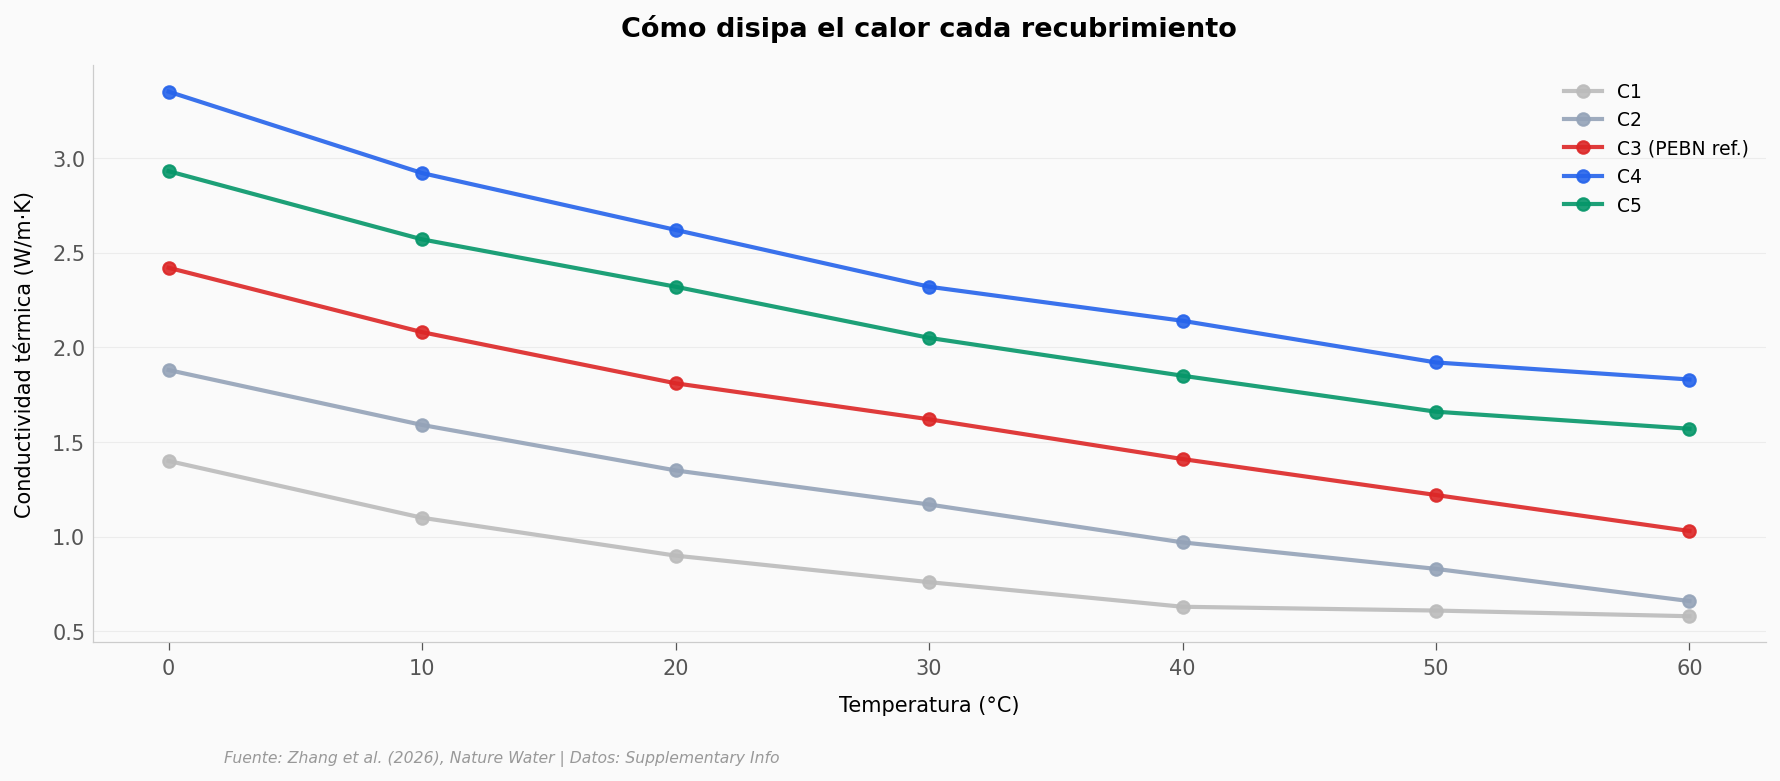


C5 supera a C3 (PEBN ref.) en 7 de 7 temperaturas medidas.
 temperature_k  k_c3_pebn_ref  k_c5
           273           2.42  2.93
           283           2.08  2.57
           293           1.81  2.32
           303           1.62  2.05
           313           1.41  1.85
           323           1.22  1.66
           333           1.03  1.57


In [6]:
# --- EXPERIMENTA AQUÍ ---
# Conductividad térmica vs temperatura de las 5 muestras del paper
fig, ax = plt.subplots(figsize=(12, 5))

temp_c = therm['temperature_k'] - 273  # K → °C (más intuitivo)
series = [
    ('k_c1',          'C1',               COLOR_CONTEXTO),
    ('k_c2',          'C2',               '#94A3B8'),
    ('k_c3_pebn_ref', 'C3 (PEBN ref.)',   COLOR_ALERTA),
    ('k_c4',          'C4',               COLOR_DATOS),
    ('k_c5',          'C5',               COLOR_SECUNDARIO),
]
for col, label, color in series:
    ax.plot(temp_c, therm[col], '-o', color=color, linewidth=2,
            markersize=6, alpha=0.9, label=label)

ax.set_xlabel('Temperatura (°C)', fontsize=10)
ax.set_ylabel('Conductividad térmica (W/m·K)', fontsize=10)
ax.set_title('Cómo disipa el calor cada recubrimiento',
             fontsize=13, fontweight='bold', pad=14)
ax.legend(fontsize=9, loc='upper right', framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.show()

# Pregunta 2: ¿a qué temperatura C5 > C3?
cruces = therm[therm['k_c5'] > therm['k_c3_pebn_ref']]
print(f'\nC5 supera a C3 (PEBN ref.) en {len(cruces)} de {len(therm)} temperaturas medidas.')
print(cruces[['temperature_k', 'k_c3_pebn_ref', 'k_c5']].to_string(index=False))


## Créditos

**Repo:** [Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab) · MIT License
**Paper:** Zhang, C. et al. (2026). *A bioinspired hierarchical architecture for the high-yield recovery of industrial water vapour*. Nature Water. [DOI:10.1038/s44221-026-00635-8](https://doi.org/10.1038/s44221-026-00635-8)
**Datos:** Supplementary Information (MOESM1, MOESM6) — Springer Nature

## Fuentes

**Paper**: [A bioinspired hierarchical architecture for the high-yield recovery of industrial water vapour](https://doi.org/10.1038/s44221-026-00635-8)  
*Nature Water, 2026-04-21*

**Datos**: [Supplementary Information MOESM6 (Source Data Fig. 5g, Fig. 5l)](https://static-content.springer.com/esm/art%3A10.1038%2Fs44221-026-00635-8/MediaObjects/44221_2026_635_MOESM6_ESM.xlsx)  
**Recubrimientos**: [Supplementary Information MOESM1 — Tabla 4](https://static-content.springer.com/esm/art%3A10.1038%2Fs44221-026-00635-8/MediaObjects/44221_2026_635_MOESM1_ESM.pdf)

*18 afirmaciones verificadas contra estas fuentes*
